# Exercise 6

This exercise is based on Chapter 4 (Spatial Weights) of the Geographic Data Science book.

The material can be found in: `GSP538/gds_book/notebooks/04_spatial_weights.ipynb`

#### Notes on Textbook

- This chapter is all about spatial relationships. You have seen most of the concepts discussed in this chapter in previous GIS courses. The additional value here is translating those general concepts into a formal structure. The chapter and this exercise is asking you to refine your existing knowledge to be able to speak precisely about spatial relationships.
- It is not necessary that you understand the code to create the 3x3 grid, but it does drive home the idea that polygons in a GIS are simply made up of points.

- If some of the cells don't run, be sure you're in the `gsp538` environment
- VS Code allows you to have side-by-side notebooks (e.g., this exercise and the book chapter).
  - Collapse the Explorer by clicking the little icon in the upper-left of VS Code
  - Click and drag the tab of the notebook you want to reposition (e.g. drag it to the right side of the VS Code window)
- Remember that the chapter is an interactive Jupyter notebook. If something is confusing or you have a question, you can insert a new cell and run your own code to see what happens.

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. How does the book define topology? How does this relate to how topology was discussed in your other GIS course(s)?

The book defines topology as a mathematical structure that expresses the **connectivity between observations**. A topology embeds all observations in space together, allowing us to examine spatial relationships across the entire dataset rather than asking isolated questions about individual features. In traditional GIS courses, topology is discussed in terms of the spatial relationships among features — shared boundaries, adjacency, containment, and connectivity — and rules that enforce geometric integrity (e.g., no gaps or overlaps between polygons). The GDS book's definition is consistent with this but formalizes it into a matrix/graph structure (the spatial weights matrix) that can be used directly in computation and analysis.

2. What is meant by a "sparse" representation of a weights matrix? What is the advantage of this way of storing the weights information?

A "sparse" representation stores only the **non-zero** entries of the weights matrix. Instead of recording every pairwise relationship (including all the zeros for non-neighbors), the sparse format uses a dictionary where each key is a focal polygon and the value is a list of its neighbors. For example, knowing that polygon 0's neighbors are polygons 1 and 3 implicitly tells us that polygons 2, 4, 5, 6, 7, and 8 are *not* neighbors, so there is no need to store those zeros. The advantage is a significant reduction in memory usage — for large datasets with thousands of observations, the full matrix would have millions of entries, but only a small fraction are non-zero. The sparse format stores only the meaningful relationships.

3. In the initial book examples, the authors are working with a 3x3 grid of cells in space. However, the non-sparse representation of the weights matrix for this grid is 9x9. Why is this?

The weights matrix is 9×9 because it represents the pairwise spatial relationships among all 9 polygons (n=9). Each row corresponds to one polygon and each column corresponds to one polygon, so the matrix has n×n = 9×9 = 81 entries. The 3×3 refers to the spatial arrangement of the grid cells on the map, but the weights matrix must capture the relationship between every possible pair of polygons, which requires an n×n matrix.

4. What is meant by the idea that relationships in time are "unidirectional", but relationships in space are "bidirectional"? 

In time, relationships are **unidirectional**: yesterday can influence today, but today cannot influence yesterday. There is a natural ordering (past → present → future) and causality flows in one direction. In space, relationships are **bidirectional**: if city A is near city B, then city B is also near city A. There is no inherent directionality or ordering to spatial relationships — influence can flow in any direction between neighbors. This bidirectionality makes spatial analysis more complex because we must account for mutual influence between observations, and the ordering of observations in the weights matrix is arbitrary rather than naturally determined.

5. Link the three concepts of "geographic tables", "spatial graphs" and "spatial weights." (Note: this question is not asking for a definition of each concept, it is asking for how these three concepts relate to one another. Hint: you might want to review Chapters 1 and 3.)

These three concepts form a connected pipeline. **Geographic tables** (GeoDataFrames) store spatial data with geometry columns that encode the location and shape of each observation. From these geometries, we can compute **spatial weights**, which formalize the neighbor relationships between observations into a matrix (e.g., which polygons share a border, which points are within a certain distance). These spatial weights can then be understood as a **spatial graph** (or network), where each observation is a node and each non-zero weight is an edge connecting two nodes. The spatial graph is essentially the visual/mathematical representation of the weights matrix. In other words: geographic tables provide the raw spatial data, spatial weights encode the relationships extracted from that data, and spatial graphs give us a network structure we can visualize and analyze using graph theory.

6. The following sentence from the book has a typo: "More specifically, polygons $0$ and $5$ are not Rook neighbors, but they do in fact share a common border." What needs to be fixed in this sentence? (Hint: fixing a typo means changing one small thing, not rewriting the sentence.)

The typo is in the polygon number: "polygons 0 and 5" should be "polygons 0 and **4**." In the 3×3 grid, polygon 0 (top-left corner) and polygon 5 (middle-right) do not share any boundary at all — not an edge, not even a vertex. However, polygon 0 and polygon **4** (the center cell) share a common vertex (diagonal corner), making them Queen neighbors but not Rook neighbors. The rest of the sentence is correct: the sharing is "due to a common vertex rather than a shared edge."

7. For each type of weights listed below state whether weights are "binary" (i.e., can only take values of zero or one) or "continuous" (i.e., can take any value). (Note: enter your answer by editing the cell below.)

- Rook: **Binary** (neighbors get 1, non-neighbors get 0)
- Queen: **Binary** (neighbors get 1, non-neighbors get 0)
- k nearest neighbors: **Binary** (the k nearest get 1, all others get 0)
- Kernel: **Continuous** (weights decrease smoothly with distance according to a kernel function)
- Distance band (basic): **Binary** (within the distance threshold = 1, beyond = 0)
- Distance band (hybrid): **Continuous** (within the threshold, weights are based on inverse distance; beyond = 0)
- Block: **Binary** (same group = 1, different group = 0)

8. Why do distance based spatial weights need to be measured using projected data or great circle distance? Why does this not matter for contiguity based spatial weights?

Distance-based spatial weights require projected data or great circle distance because they involve computing actual **distances** between observations. If you use unprojected latitude/longitude coordinates (which are in degrees), a simple Euclidean distance calculation would be incorrect — one degree of longitude varies in length depending on latitude, and straight-line distance in degree-space ignores the curvature of the Earth. Projected coordinate systems convert to a flat surface with consistent distance units (e.g., meters), and great circle distance accounts for Earth's curvature mathematically. Without one of these approaches, the computed distances (and therefore the weights) will be wrong, potentially leading to erroneous neighbor assignments.

Contiguity-based weights (Rook, Queen) do not need this because they only ask whether two polygons **touch** — they examine shared edges or vertices in the geometry, which is a purely topological question. No distance measurement is involved, so the coordinate system's distance properties are irrelevant.

9. The authors mentioned that rook weights are symmetrical. This means that if Polygon5 is a rook neighbor of Polygon7, then it is necessarily true that Polygon5 is a rook neighbor of Polygon7. However, k nearest neighbor weights are not necessarily symmetrical. If we identify the 4 nearest neighbors (KNN4) for each polygon and find that Polygon5 is a KNN4 neighbor of Polygon7, then Polygon7 may or may not be a KNN4 neighbor of Polygon5. Explain why rook weights are symmetrical and k nearest neighbor weights are not necessarily symmetrical. (Hint: drawing some polygons with pen and paper might make these ideas more concrete.)

**Rook weights are symmetric** because the relationship is based on shared edges, which is inherently mutual. If polygon A shares an edge with polygon B, then polygon B necessarily shares that same edge with polygon A. There is no scenario where A touches B but B does not touch A.

**KNN weights are not necessarily symmetric** because each polygon independently picks its k closest neighbors based on distance. Consider three polygons: A is isolated, B is near A, and C is very close to B. If k=1, polygon A's nearest neighbor might be B, so A lists B as a neighbor. But B's nearest neighbor is C (which is closer), so B does *not* list A. The result is that A→B exists but B→A does not. Each polygon has exactly k outgoing connections (out-degree = k), but the number of times a polygon is chosen by others (in-degree) varies, breaking symmetry.

#### The following questions require you to run Python code.

The cell below imports the GeoPandas package and the standard extra stuff to make things run smoother. Run this cell. 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd

10. The Town of Cary, North Carolina provides spatial data on their trash collection services. You can see the metadata and other information at the following link.
https://data.townofcary.org/explore/dataset/solid-waste-and-recycling-collection-routes

    Run the following cell. The first two lines read in census tract and town data from the US Census Bureau. The lines labeled `L1` to `L6` read in the trash collection data from the town. After running the cell, explain what each line from `L1` to `L6` is doing.

In [2]:
tracts = gpd.read_file('data/cary_tracts.geojson')
cary = gpd.read_file('data/cary.geojson')

trash = gpd.read_file('data/cary_trash_collection_zones.geojson') #L1
trash = trash.loc[~trash.geometry.isna(),] #L2
trash = trash.explode() #L3
trash = trash.reset_index() #L4
trash = trash.drop(columns=['index','geo_shape']) #L5
trash = trash.to_crs(tracts.crs) #L6

- **L1:** Reads the Cary trash collection zones GeoJSON file into a GeoDataFrame called `trash`.
- **L2:** Removes any rows that have missing (NaN) geometry. The `~` operator negates the boolean mask, so this keeps only rows where geometry is *not* null.
- **L3:** Explodes multi-part geometries into individual single-part geometries. If a trash collection zone is stored as a MultiPolygon, each polygon becomes its own row.
- **L4:** Resets the index of the DataFrame. After `explode()`, the index becomes a MultiIndex; `reset_index()` converts it back to a simple integer index.
- **L5:** Drops the `index` column (created by `reset_index()` from the old MultiIndex) and the `geo_shape` column (which was an alternative geometry representation from the original data that is no longer needed).
- **L6:** Reprojects the `trash` GeoDataFrame to match the coordinate reference system (CRS) of the `tracts` GeoDataFrame, ensuring both datasets are in the same CRS for spatial analysis.

11. Starting from the output of the previous question, create a new `trash` GeoDataFrame, that has the `square_miles` column removed. Why is the `square_miles` column no longer relevant? (Hint: look at the steps from the previous code cell.)

In [3]:
trash = trash.drop(columns=['square_miles'])
trash.head()

,day,cycle,rec_pickup,sw_pickup,yw_pickup,geo_point_2d,geometry
0,Tuesday,Yellow,Yes,Yes,Yes,"{'lon': -78.82871239673686, 'lat': 35.79412588...","POLYGON ((1530312.275 -52656.877, 1530312.409 ..."
1,Tuesday,Yellow,Yes,Yes,Yes,"{'lon': -78.82871239673686, 'lat': 35.79412588...","POLYGON ((1529714.438 -52524.517, 1529702.737 ..."
2,Tuesday,Yellow,Yes,Yes,Yes,"{'lon': -78.82871239673686, 'lat': 35.79412588...","POLYGON ((1529912.15 -52580.386, 1529907.957 -..."
3,Tuesday,Yellow,Yes,Yes,Yes,"{'lon': -78.82871239673686, 'lat': 35.79412588...","POLYGON ((1529506.707 -52085.751, 1529500.205 ..."
4,Tuesday,Yellow,Yes,Yes,Yes,"{'lon': -78.82871239673686, 'lat': 35.79412588...","POLYGON ((1529884.983 -52631.72, 1529879.578 -..."


The `square_miles` column is no longer relevant because `explode()` (L3) split multi-part geometries into individual single-part polygons. The original `square_miles` value was computed for the entire multi-part collection zone, but after exploding, each row represents just one piece of that zone. The original area value no longer accurately describes the area of each individual polygon — it would need to be recalculated for each exploded part.

12. Run the following cell to see how the city is split by recycling week (see the metadata if you have questions). After running the cell, create a single map showing how the city is split by day of the week. (Note: make your map large like the recycling map and pick some nice colors and don't reuse the recycling colors https://matplotlib.org/stable/gallery/color/named_colors.html#css-colors.)

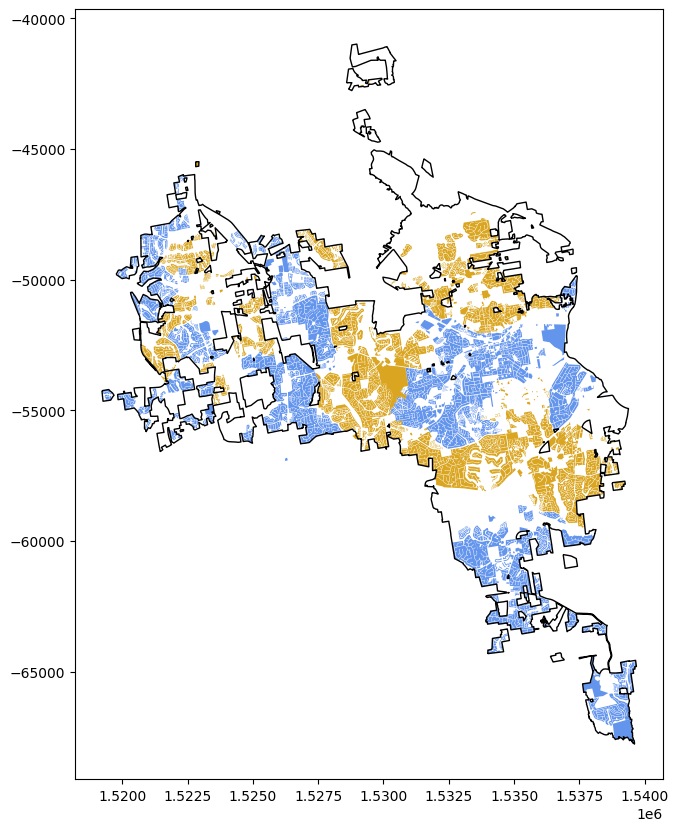

In [4]:
ax = trash.loc[trash.cycle=='Blue',].plot(color='cornflowerblue', figsize=(10,10))
trash.loc[trash.cycle=='Yellow',].plot(color='goldenrod', ax=ax)
cary.boundary.plot(linewidth=1, color='black', ax=ax);

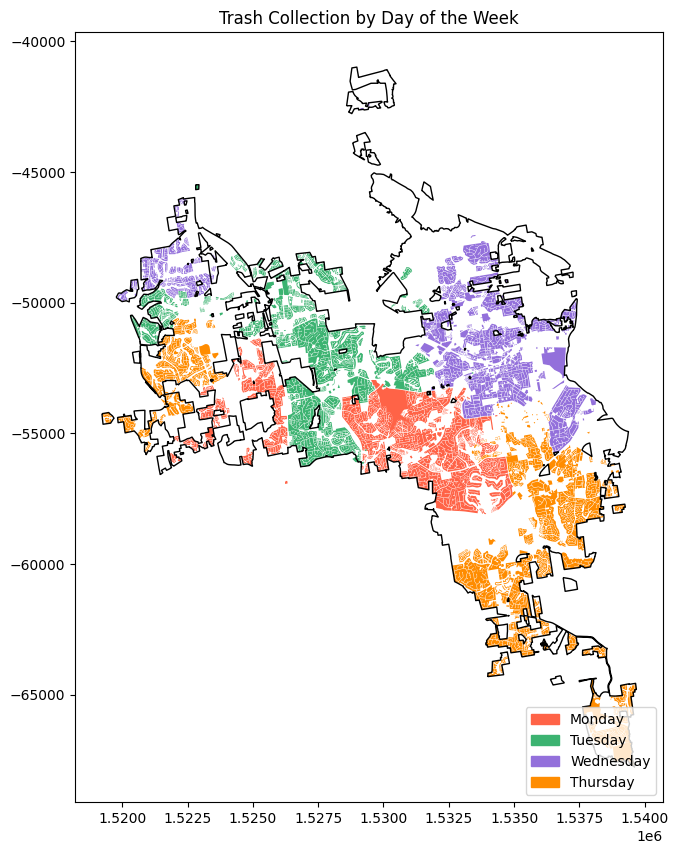

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

day_colors = {'Monday': 'tomato', 'Tuesday': 'mediumseagreen',
              'Wednesday': 'mediumpurple', 'Thursday': 'darkorange'}

ax = trash.loc[trash.day=='Monday',].plot(color='tomato', figsize=(10,10))
trash.loc[trash.day=='Tuesday',].plot(color='mediumseagreen', ax=ax)
trash.loc[trash.day=='Wednesday',].plot(color='mediumpurple', ax=ax)
trash.loc[trash.day=='Thursday',].plot(color='darkorange', ax=ax)
cary.boundary.plot(linewidth=1, color='black', ax=ax)
ax.set_title('Trash Collection by Day of the Week')
patches = [mpatches.Patch(color=c, label=d) for d, c in day_colors.items()]
ax.legend(handles=patches, loc='lower right');

13. Create rook spatial weights for the Cary `tracts`. Then plot the resulting spatial relationships on a map similar to the San Diego map in the book. (Note: the textbook plot has two maps so the code is a little more complicated than what is being asked here. Note: the map should be large like the previous plots.)

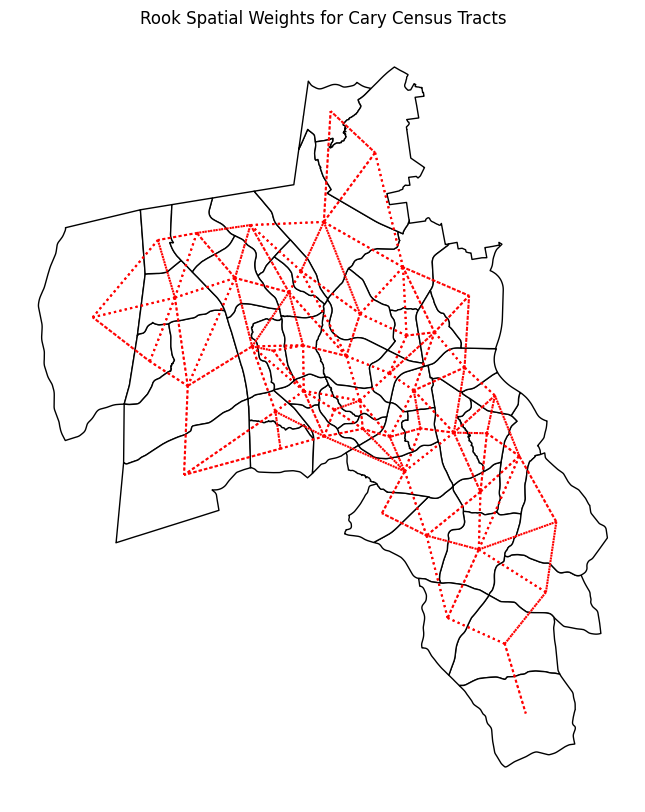

In [6]:
from libpysal import weights
import matplotlib.pyplot as plt

w_rook = weights.contiguity.Rook.from_dataframe(tracts)

f, ax = plt.subplots(1, 1, figsize=(10, 10))
tracts.plot(facecolor='w', edgecolor='k', ax=ax)
w_rook.plot(tracts, edge_kws=dict(color='r', linestyle=':'), node_kws=dict(marker=''), ax=ax)
ax.set_title('Rook Spatial Weights for Cary Census Tracts')
ax.set_axis_off();

14. Look closely at the map you produced for the previous question. How many MORE lines do you think will be on the map for the queen case? Write down your answer now.

    - Create queen spatial weights for `tracts`.
    - Reproduce the map above (tract outlines and rook connections), but this time plot the queen connections too. Rook should be the last layer added and use different color lines from queen connections.
    - Report the value of the `nonzero` attribute for the queen and rook weights.
    - In a Markdown cell, discuss whether you over or under estimated the number of additional linkages, and why.

Rook nonzero: 224
Queen nonzero: 250
Additional queen connections: 26


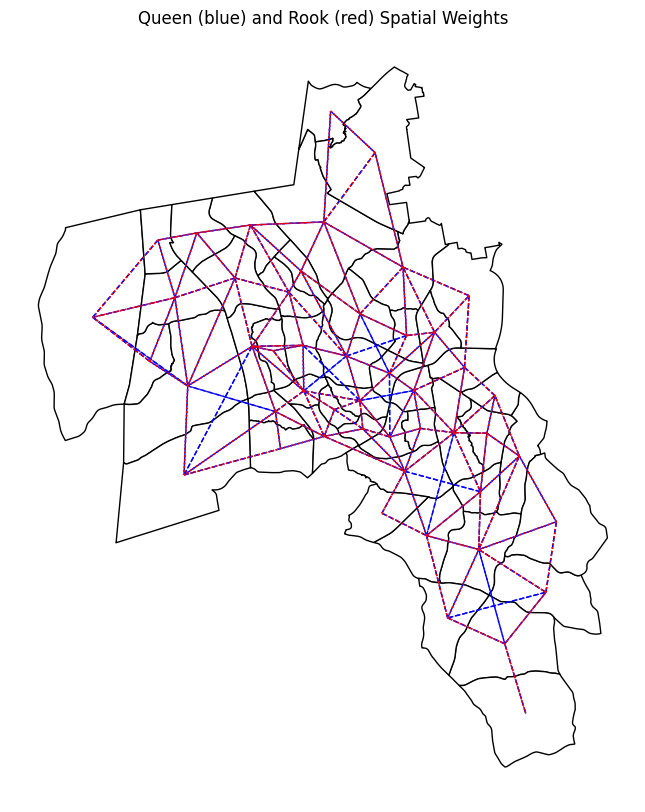

In [7]:
w_queen = weights.contiguity.Queen.from_dataframe(tracts)

f, ax = plt.subplots(1, 1, figsize=(10, 10))
tracts.plot(facecolor='w', edgecolor='k', ax=ax)
w_queen.plot(tracts, edge_kws=dict(color='blue', linestyle='--', linewidth=1), node_kws=dict(marker=''), ax=ax)
w_rook.plot(tracts, edge_kws=dict(color='r', linestyle=':', linewidth=1), node_kws=dict(marker=''), ax=ax)
ax.set_title('Queen (blue) and Rook (red) Spatial Weights')
ax.set_axis_off()

print(f"Rook nonzero: {w_rook.nonzero}")
print(f"Queen nonzero: {w_queen.nonzero}")
print(f"Additional queen connections: {w_queen.nonzero - w_rook.nonzero}")

**Estimate:** I estimated there would be around 10-15 additional lines for the queen case compared to the rook case.

**Actual result:** The queen weights have 250 non-zero entries compared to 224 for rook — that's 26 additional connections (13 additional unique pairs, since each pair is counted twice in the symmetric matrix). This means roughly 13 more lines on the map.

I slightly underestimated the number of additional linkages. The additional connections come from tracts that share only a single vertex (corner point) rather than an edge. Because most census tract boundaries meet at T-intersections (where three tracts come together) rather than at four-way crossroads (where four tracts meet at a single point), there are relatively few vertex-only connections compared to the total number of edge-based connections. The queen case adds only a modest number of new links on top of the rook connections.

15. Create kernel spatial weights for `tracts`.
    - When creating the weights, explicitly pass in a value to the `bandwidth` parameter.
    - Make the same style map as above, this time with just the kernel weight connections and the tract outlines.
    - Explain what the `bandwidth` parameter does, its units and why you chose the particular value you did. Do all the tracts have neighbors? Why or why not?

Islands: []
Number of islands: 0


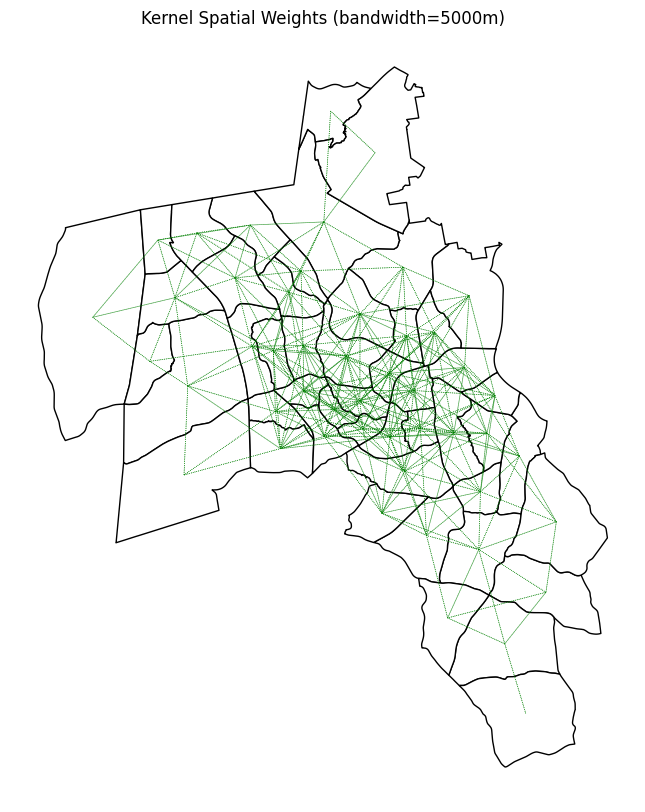

In [8]:
w_kernel = weights.distance.Kernel.from_dataframe(tracts, bandwidth=5000)

f, ax = plt.subplots(1, 1, figsize=(10, 10))
tracts.plot(facecolor='w', edgecolor='k', ax=ax)
w_kernel.plot(tracts, edge_kws=dict(color='green', linestyle=':', linewidth=0.5), node_kws=dict(marker=''), ax=ax)
ax.set_title('Kernel Spatial Weights (bandwidth=5000m)')
ax.set_axis_off()

print(f"Islands: {w_kernel.islands}")
print(f"Number of islands: {len(w_kernel.islands)}")

The `bandwidth` parameter defines the maximum distance (in the CRS units — meters in this case) within which two observations are considered neighbors. Any pair of tract centroids within 5,000 meters of each other receives a non-zero weight, and pairs beyond 5,000 meters receive zero weight. The weight value itself decays with distance according to the kernel function (triangular by default), so closer tracts receive higher weights than more distant ones within the bandwidth.

I chose 5,000 meters (5 km) because the study area spans roughly 25 km × 30 km, and the tracts vary in size from small urban parcels to larger suburban areas. A 5 km bandwidth ensures that all tracts have at least some neighbors while avoiding connecting tracts that are very far apart. All tracts have neighbors (zero islands) because 5 km is large enough that every tract centroid is within 5 km of at least one other tract centroid. If a smaller bandwidth were chosen (e.g., 1,000 m), some of the larger, more isolated peripheral tracts might become islands.

16. Create queen spatial weights for `trash`. What percentage of the `trash` polygons are islands (when using queen weights)? What percentage of the `tracts` polygons are islands (when using queen weights)? Explain why the two percentages are so different. (Note: you need to compute the percentage being requested here, it is different from `pct_nonzero` discussed in the book. Hint: `trash.explore()` might help answer the "why" question.)

In [9]:
w_queen_trash = weights.contiguity.Queen.from_dataframe(trash)

pct_islands_trash = 100 * len(w_queen_trash.islands) / len(trash)
pct_islands_tracts = 100 * len(w_queen.islands) / len(tracts)

print(f"Trash: {len(w_queen_trash.islands)} islands out of {len(trash)} polygons = {pct_islands_trash:.2f}%")
print(f"Tracts: {len(w_queen.islands)} islands out of {len(tracts)} polygons = {pct_islands_tracts:.2f}%")

Trash: 3666 islands out of 4792 polygons = 76.50%
Tracts: 0 islands out of 49 polygons = 0.00%


**76.50%** of trash polygons are islands, while **0.00%** of tract polygons are islands.

The percentages are so different because of the nature of the two datasets. Census tracts are designed to tile a region completely — they share edges with their neighbors, forming a seamless mosaic with no gaps. Every tract touches at least one other tract, so there are no islands.

The trash collection zones, on the other hand, were exploded from multi-part geometries into thousands of tiny individual polygons. Many of these individual pieces are small, isolated fragments (e.g., individual parcels, cul-de-sacs, or disconnected parts of a collection route) that do not physically touch any other polygon. If you use `trash.explore()`, you can see that many of these fragments are scattered and separated by roads, open spaces, or areas not covered by the collection service. Since queen contiguity requires at least a shared vertex, these isolated fragments have no queen neighbors and are classified as islands.

17. Create block spatial weights for `trash` based on day of the week. Report `nonzero` and `pct_nonzero` on the block weights result and the queen weights result for `trash`. Why is the block result so much more connected than the queen result? (Note: the book example for block weights creation uses an _optional_ `ids` parameter, you do not need it.)

In [10]:
w_block_trash = weights.util.block_weights(trash['day'].values)

print("Block weights:")
print(f"  nonzero: {w_block_trash.nonzero}")
print(f"  pct_nonzero: {w_block_trash.pct_nonzero:.4f}%")
print()
print("Queen weights (trash):")
print(f"  nonzero: {w_queen_trash.nonzero}")
print(f"  pct_nonzero: {w_queen_trash.pct_nonzero:.4f}%")

Block weights:
  nonzero: 5776622
  pct_nonzero: 25.1559%

Queen weights (trash):
  nonzero: 1704
  pct_nonzero: 0.0074%


The block weights result is enormously more connected than the queen result (5,776,622 non-zero entries vs. 1,704; 25.16% vs. 0.0074%). This is because block weights connect **every polygon to every other polygon in the same group**, regardless of physical proximity. With only 4 days (Monday–Thursday), each block contains roughly 1,200 polygons, and every polygon in a block is connected to every other polygon in that block — that's about 1,200 × 1,199 = ~1.44 million connections per block, times 4 blocks.

Queen weights, by contrast, only connect polygons that physically touch (share an edge or vertex). Since the trash data has thousands of tiny, isolated polygon fragments, most polygons don't touch any other polygon at all (76.5% are islands). Block weights completely ignore spatial relationships and use only the categorical grouping, which produces a vastly denser network of connections.

18. In an earlier question, you explored how bandwidth works in relation to kernel weights. Here you will explore the kernel function options. 

    The first cell below computes kernel weights for `trash` using the default kernel function (triangular) and a bandwidth of 500. It shows that for this bandwidth you get over 180,000 connections.

    The second cell has a lot of code. The first function (`get_dists`) computes the distance between each of the 180,000 pairs of polygons. The second function (`plot_kernel`) creates a scatter plot of the distance between the 180,000 pairs (on the x axis) and the weight between the 180,000 pairs (on the y axis). You do not need to understand the code itself, just the output of the `plot_kernel` function.
   
    The last four cells run `plot_kernel` for four different kernel functions. A mathematical description of each kernel can be found at: https://pysal.org/libpysal/generated/libpysal.weights.Kernel.html.
   
    Run all the cells and then describe how the weight differs by distance for each kernel function. Your answer should include a description of each kernel's shape and the implied importance the user is putting on different distances if they were to choose that particular kernel. (Hint: they are all different. Also, do not say something like, "weights change quadratically" since we already know this from the kernel name. Your descriptions should be for a non-technical audience.)

In [11]:
wk_trash = weights.distance.Kernel.from_dataframe(trash, bandwidth=500)
wk_trash.nonzero

182446

In [12]:
import pandas as pd

# function that computes the distances between polygons up to a specified bandwidth
def get_dists(bw):
    w_kernel = weights.distance.Kernel.from_dataframe(trash, bandwidth=bw)   # triangular weights
    dists = {}                       # empty dictionary to hold distances
    for focal_id, wghts in w_kernel.weights.items():   # iterate over the focal IDs
        dists_temp = []              # holder for distance values
        for weight in wghts:         # iterate over the weights for a particular focal ID
            dist = bw * (1 - weight) # convert triangular weight to distance
            dists_temp.append(dist)  # add distance to holder list
        dists[focal_id] = dists_temp # store all distances for a particular focal ID
    return dists

# function that plots weights against distance for a particular type of kernel
def plot_kernel(bw, kernel, dists):
    dist_weight = []                                   # holder of distances and weights
    w_kernel = weights.distance.Kernel.from_dataframe(trash, bandwidth=bw, function=kernel)   # get weights
    for focal_id, wghts in w_kernel.weights.items():   # iterate over focal IDs
        pairs = zip(dists[focal_id], wghts)            # align distances to corresponding weights
        dist_weight.extend(pairs)                      # add the distance weight pairs to the holder 
    dist_weight_df = pd.DataFrame(dist_weight, columns=['dist','weight'])   # create DataFrame for plotting
    dist_weight_df.plot.scatter(x='dist', y='weight'); # create a scatter plot

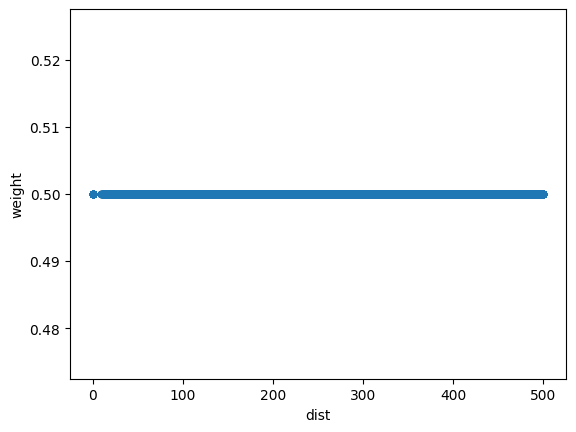

In [13]:
bw = 500
dists = get_dists(bw)
plot_kernel(bw, 'uniform', dists)

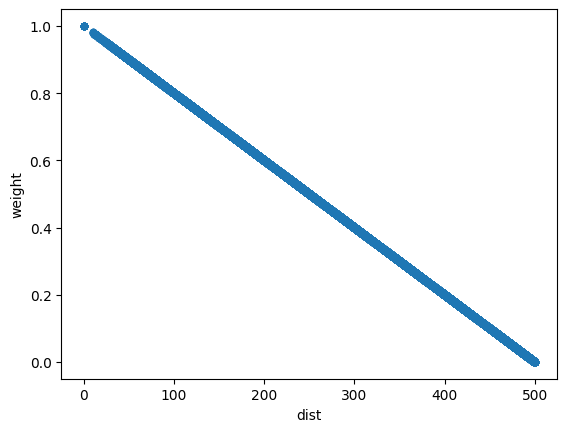

In [14]:
bw = 500
dists = get_dists(bw)
plot_kernel(bw, 'triangular', dists)

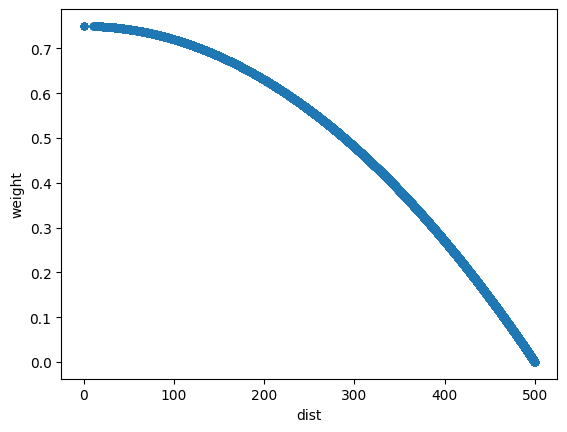

In [15]:
bw = 500
dists = get_dists(bw)
plot_kernel(bw, 'quadratic', dists)

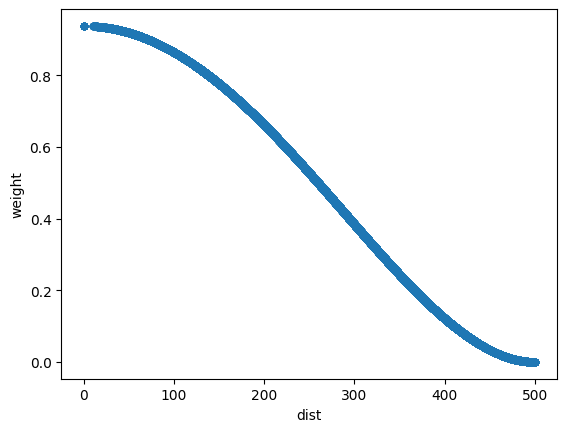

In [16]:
bw = 500
dists = get_dists(bw)
plot_kernel(bw, 'quartic', dists)

**Uniform:** The weight is exactly the same (0.5) regardless of distance. A neighbor 10 meters away is treated identically to a neighbor 490 meters away. This kernel implies that the user believes all neighbors within the bandwidth are equally important — distance doesn't matter at all, only whether you're "in" or "out."

**Triangular:** Weights start at 1.0 for the closest neighbors and decline in a straight line down to 0.0 at the bandwidth edge. The decline is steady and even — for every additional meter of distance, the weight drops by the same amount. This implies the user believes importance fades at a constant, predictable rate — each step farther away reduces the influence by the same amount.

**Quadratic:** Weights start high (~0.75) and hold relatively steady for nearby neighbors, then curve downward more and more steeply as distance increases. Close neighbors retain a lot of influence while distant neighbors lose importance increasingly quickly. This implies the user believes nearby areas are about equally important, but that influence drops off faster and faster at greater distances — a gentle start with a steep finish.

**Quartic:** Similar to the quadratic but even more extreme. Weights start high (~0.94) and stay high for the closest neighbors, with an S-shaped curve that remains relatively flat at short distances, then plunges steeply in the middle range, and levels off again near zero at the bandwidth edge. This implies the user believes that only truly nearby neighbors matter much — there is a strong emphasis on the closest observations while more distant ones are aggressively downweighted. It draws a sharper distinction between "near" and "far" than any of the other kernels.